In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import random

C:\Users\vyash\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\__init__.py:169: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 [==============================] - 7s 1us/step


In [3]:
type(x_train)

numpy.ndarray

In [5]:
x_train.shape

(60000, 28, 28)

In [6]:
x_test.shape

(10000, 28, 28)

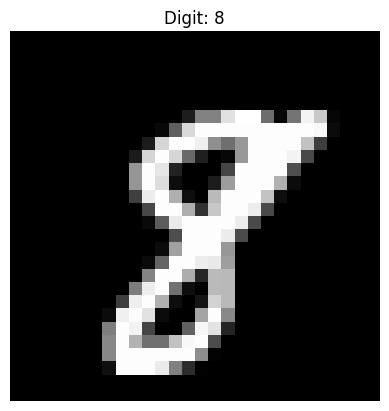

In [9]:
plt.imshow(x_train[55],cmap='gray')
plt.title(f"Digit: {y_train[55]}")
plt.axis('off')
plt.show()

In [10]:
x_train.max()

255

In [11]:
x_train.min()

0

In [12]:
# normalizing the data 
x_train,x_test = x_train/255.0 , x_test/255.0


In [13]:
x_train.max()

1.0

In [14]:
x_train.min()

0.0

In [16]:
x_train[1].shape

(28, 28)

In [18]:
# Flatten 28x28 images into 784-dimensional vectors
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

In [19]:
x_train[1].shape

(784,)

In [21]:
model = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(256,activation='relu'), #hidden layer 1
    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dense(64,activation='relu'),
    keras.layers.Dense(10,activation='softmax')
])

In [22]:
model.compile(optimizer='adam',
             loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

In [23]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               200960    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 10)                650       
                                                                 
Total params: 242762 (948.29 KB)
Trainable params: 242762 (948.29 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [24]:
history = model.fit(x_train,y_train,epochs=50,batch_size=32,validation_data=(x_test,y_test))

Epoch 1/50


1875/1875 [==============================] - 18s 9ms/step - loss: 0.2132 - accuracy: 0.9368 - val_loss: 0.0943 - val_accuracy: 0.9693
Epoch 2/50
1875/1875 [==============================] - 13s 7ms/step - loss: 0.0912 - accuracy: 0.9721 - val_loss: 0.0866 - val_accuracy: 0.9722
Epoch 3/50
1875/1875 [==============================] - 13s 7ms/step - loss: 0.0650 - accuracy: 0.9794 - val_loss: 0.0765 - val_accuracy: 0.9759
Epoch 4/50
1875/1875 [==============================] - 12s 7ms/step - loss: 0.0504 - accuracy: 0.9843 - val_loss: 0.0806 - val_accuracy: 0.9761
Epoch 5/50
1875/1875 [==============================] - 13s 7ms/step - loss: 0.0417 - accuracy: 0.9864 - val_loss: 0.0849 - val_accuracy: 0.9760
Epoch 6/50
1875/1875 [==============================] - 15s 8ms/step - loss: 0.0341 - accuracy: 0.9891 - val_loss: 0.0843 - val_accuracy: 0.9773
Epoch 7/50
1875/1875 [==============================] - 14s 7ms/step - loss: 0.0300 - accuracy: 0.9901 - val_loss: 0.0810 - val_

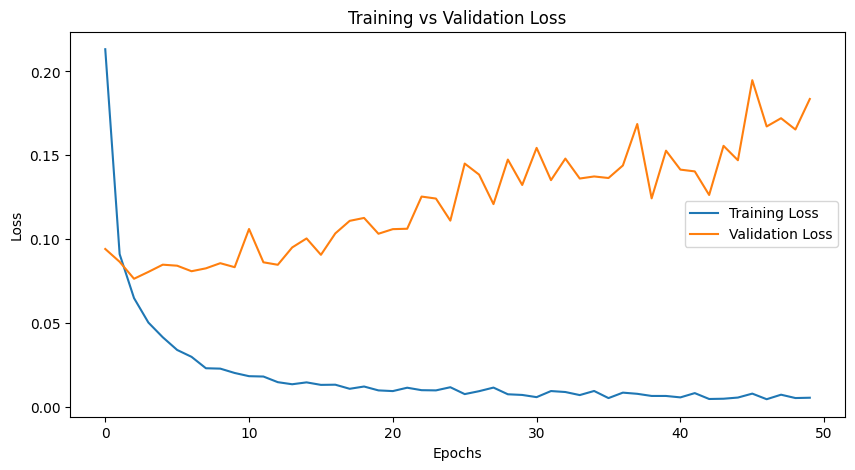

In [25]:
# Plot Training & Validation Loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [26]:
# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

313/313 [==============================] - 1s 2ms/step - loss: 0.1836 - accuracy: 0.9803
Test accuracy: 0.9803


In [27]:
# Predict on test images
predictions = model.predict(x_test)

313/313 [==============================] - 2s 4ms/step


In [28]:
# Display an example
def plot_image(index):
    plt.imshow(x_test[index].reshape(28, 28), cmap='gray')
    plt.title(f"Predicted: {np.argmax(predictions[index])}, Actual: {y_test[index]}")
    plt.axis('off')
    plt.show()

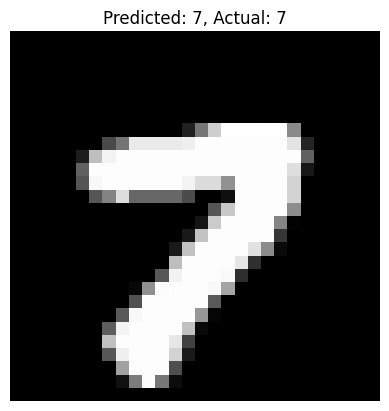

In [33]:
plot_image(79)

In [ ]:
## download leaf desease data from plantdoc 